In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings("ignore")

# ---------- configuration ----------
DEFAULT_N_TOP = 10
DATE_COL = "Date"
TIMESTAMP_COL = "Timestamp"


# ---------- data loading ----------
def load_tvl_data(path: str) -> pd.DataFrame:
    """
    Load daily TVL (Total Value Locked) data per protocol/chain.

    - Parses a date column to a DatetimeIndex.
    - Drops the raw timestamp column if present.
    - Fills missing values with zero.

    Assumes: one date column and the rest are numeric TVL columns.
    """
    df = pd.read_csv(path)

    if DATE_COL not in df.columns:
        raise ValueError(f"Expected date column '{DATE_COL}' in CSV.")

    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df.set_index(DATE_COL, inplace=True)
    df.index.name = "date"

    if TIMESTAMP_COL in df.columns:
        df = df.drop(columns=TIMESTAMP_COL)

    # Ensure numeric dtype for TVL columns
    df = df.apply(pd.to_numeric, errors="coerce")

    # Missing TVL treated as zero; change to .fillna(method="ffill") if you prefer
    df = df.fillna(0)

    return df


# ---------- selection ----------
def get_top_n_protocols(tvl_df: pd.DataFrame, n: int = DEFAULT_N_TOP) -> pd.Index:
    """
    Rank protocols by their average TVL over the full period
    and return the top n, sorted from largest to smallest.
    """
    average_values = tvl_df.mean(axis=0)  # column-wise mean
    top_n_protocols = average_values.nlargest(n).index
    return top_n_protocols


# ---------- plotting ----------
def plot_top_tvl_stacked_area(
    tvl_df: pd.DataFrame,
    top_protocols: pd.Index,
    save_path: str | None = None,
    figsize: tuple[int, int] = (20, 12),
) -> plt.Figure:
    """
    Stacked area chart of the top-N protocols by average TVL,
    largest protocol plotted on top of the stack.
    """
    plt.rcParams["font.family"] = "serif"
    fig, ax = plt.subplots(figsize=figsize)

    # Color map
    cmap = plt.get_cmap("tab20")
    n = len(top_protocols)
    colors = [cmap(i % 20) for i in range(n)]

    # Smallest at bottom, largest at top in the stack
    plot_order = top_protocols[::-1]
    stack_df = tvl_df[plot_order]

    ax.stackplot(stack_df.index, stack_df.T.values, labels=plot_order, colors=colors)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

    ax.set_ylabel("TVL (USD)", fontsize=20)
    ax.tick_params(axis="both", labelsize=16)

    # Legend largest-to-smallest
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[::-1],
        labels[::-1],
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
        fontsize=14,
        frameon=False,
    )

    fig.patch.set_alpha(0)
    ax.set_facecolor("none")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=200, transparent=True, bbox_inches="tight")

    plt.show()
    return fig



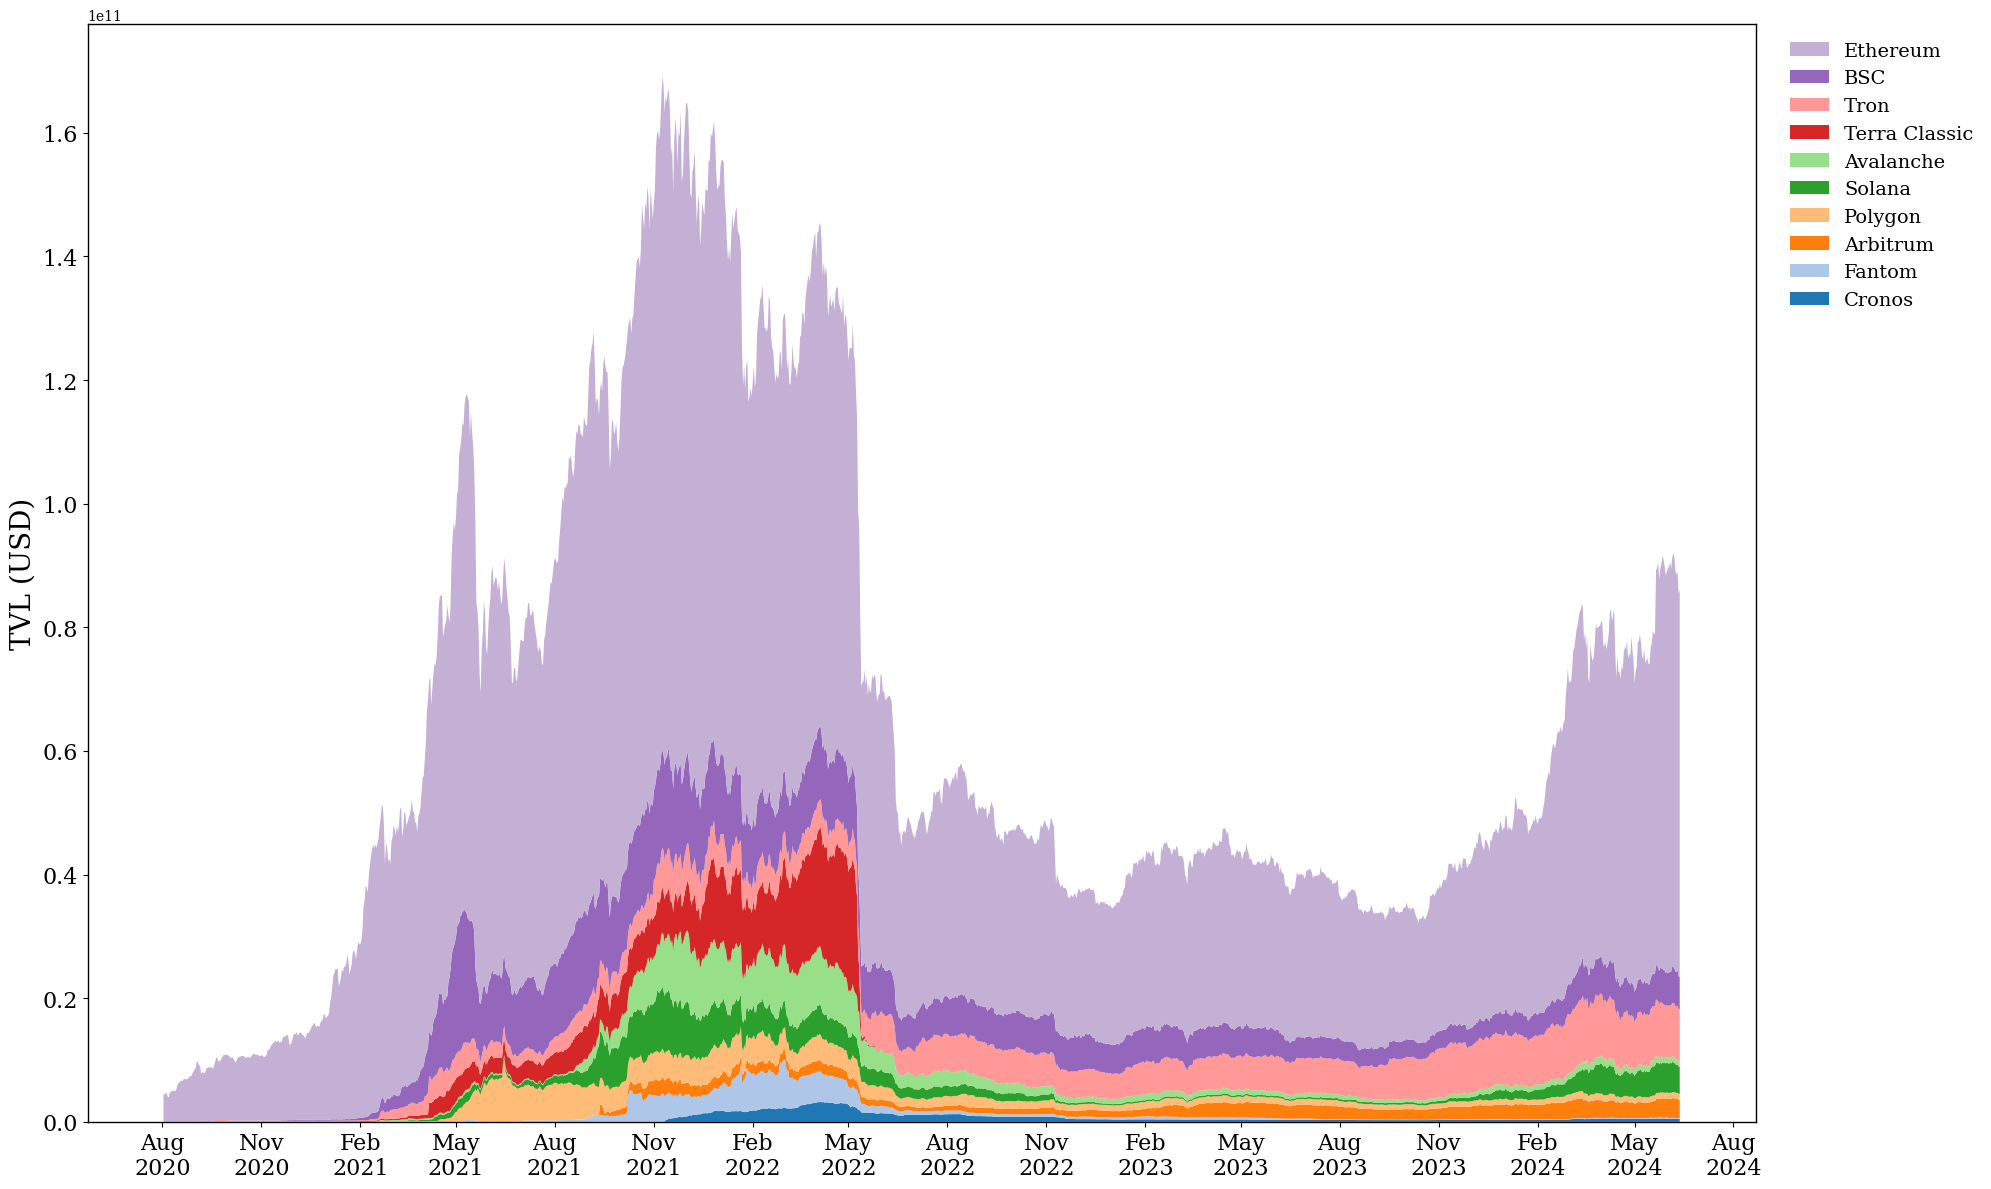

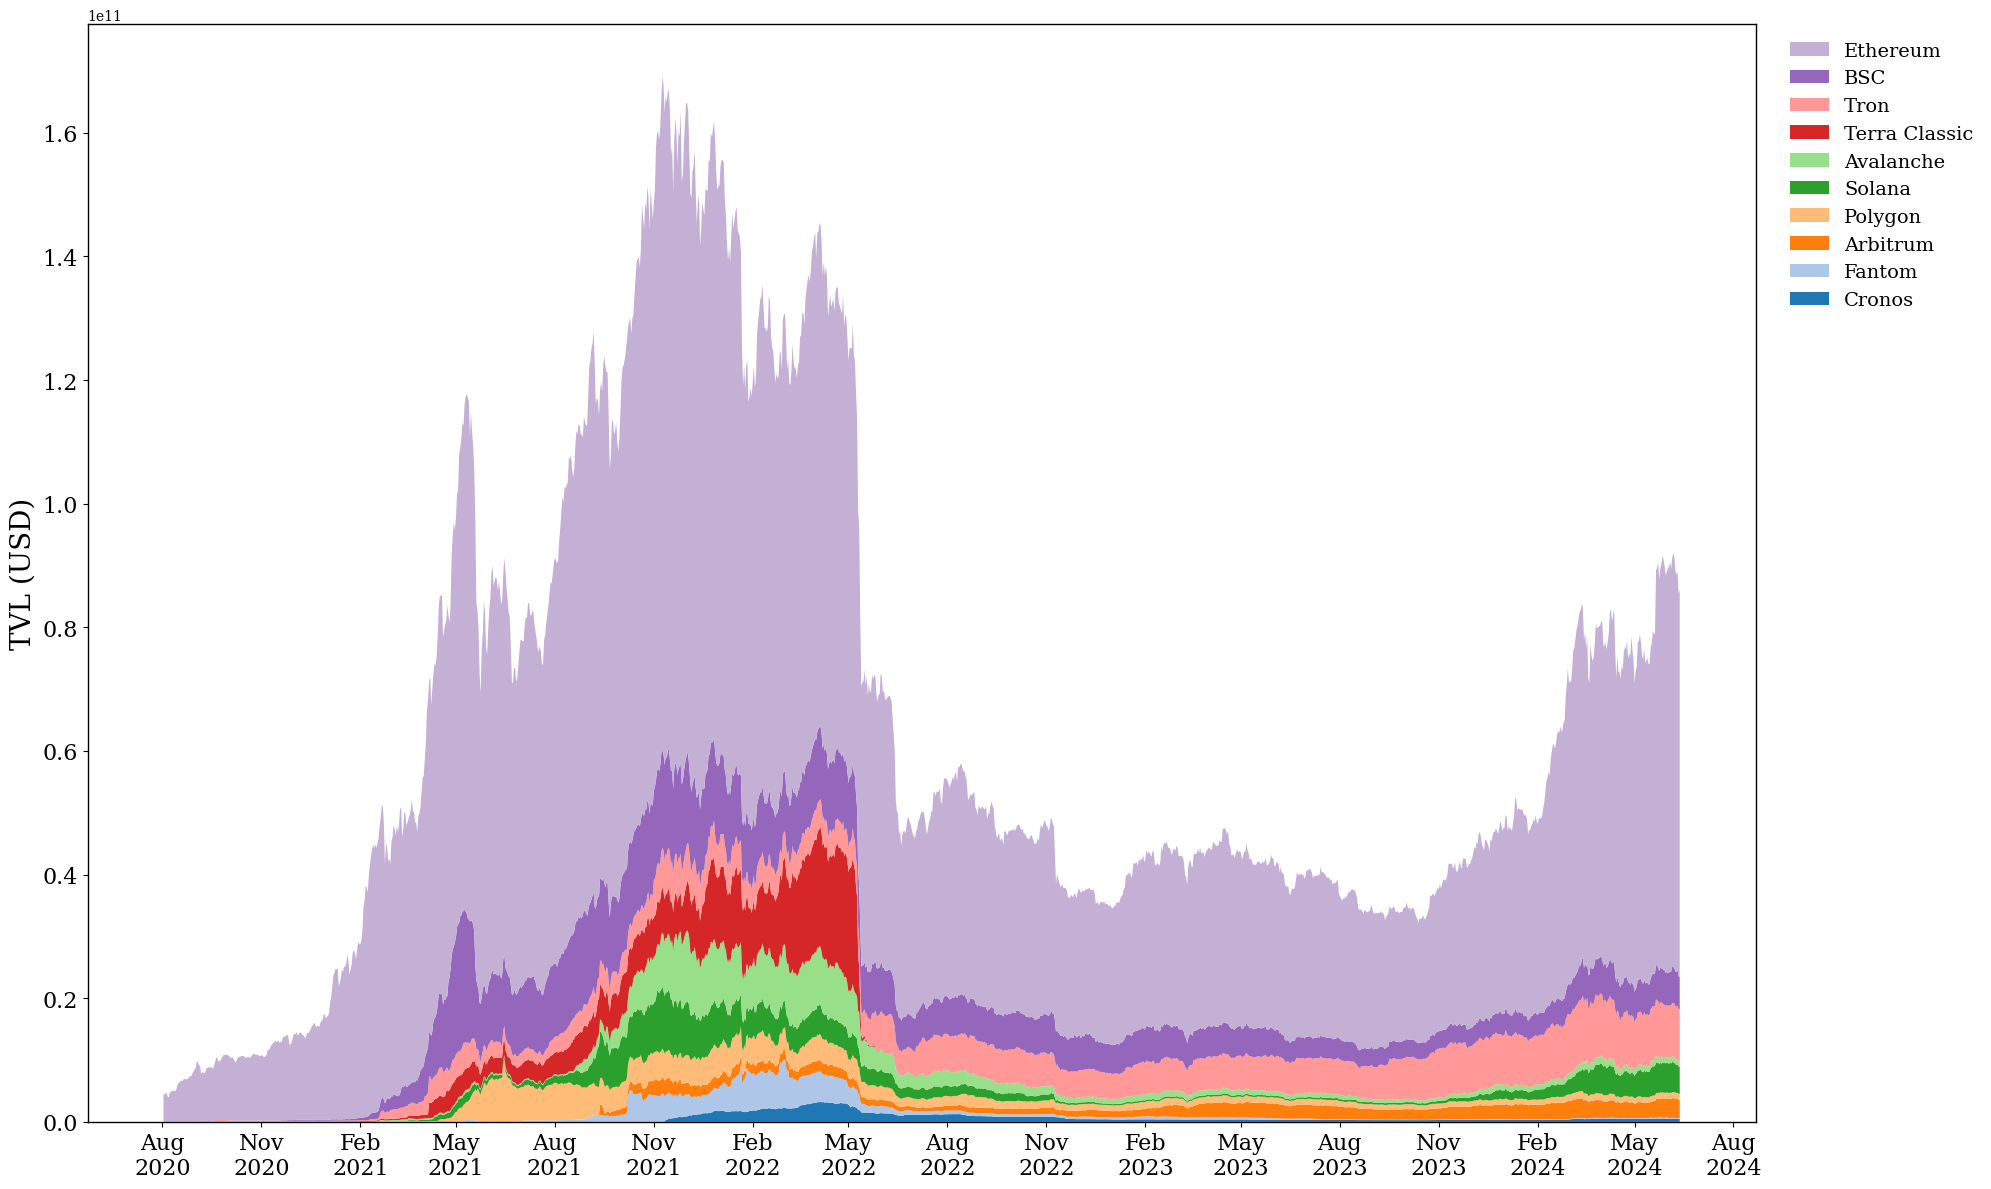

In [7]:
tvl_df = load_tvl_data("../Data/chains.csv")
top_protocols = get_top_n_protocols(tvl_df, n=DEFAULT_N_TOP)
plot_top_tvl_stacked_area(tvl_df, top_protocols, save_path="tvl_top10.png")